In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Summary_of_Results_3_18_2026.csv")
print("--- DATASET SHAPE ---")
print(df.shape, "\n")
print("--- DATA TYPES ---")
print(df.dtypes, "\n")
df.head()

--- DATASET SHAPE ---
(3592, 13) 

--- DATA TYPES ---
CERT        float64
CHCLASS1     object
CITYST       object
COST        float64
FAILDATE     object
FIN           int64
ID            int64
NAME         object
QBFASSET    float64
QBFDEP      float64
RESTYPE      object
RESTYPE1     object
SAVR         object
dtype: object 



,CERT,CHCLASS1,CITYST,COST,FAILDATE,FIN,ID,NAME,QBFASSET,QBFDEP,RESTYPE,RESTYPE1,SAVR
0,13797.0,NM,"TAYLOR, NE",1653.0,5/31/1985,2466,1000,BANK OF TAYLOR,14542.0,13360.0,FAILURE,PA,FDIC
1,18388.0,NM,"FAIRFIELD, NE",1656.0,5/31/1985,6571,1001,FAIRFIELD STATE BANK,6795.0,6034.0,FAILURE,PO,FDIC
2,18738.0,NM,"EDGAR, NE",1118.0,5/31/1985,2469,1002,SECURITY STATE BANK,6570.0,6072.0,FAILURE,PA,FDIC
3,19117.0,NM,"OAK, NE",165.0,5/31/1985,6570,1003,SCROGGIN & COMPANY BANK,3552.0,3219.0,FAILURE,PO,FDIC
4,30965.0,SL,"SAN DIEGO, CA",327146.0,5/31/1985,1706,1004,CENTRAL S&LA,2308903.0,1680711.0,ASSISTANCE,A/A,FSLIC


# Bank Failure Prediction: Exploratory Data Analysis (EDA)

## 1. Data Dictionary

Before proceeding with data preprocessing and visualization, it is essential to define the features available in our dataset. 

### A. Numerical, Text & Date Features
| Feature | Description | Format / Examples | Analytical Notes |
| :--- | :--- | :--- | :--- |
| **NAME** | The bank’s official name | Text (*"Silicon Valley Bank"*) | Ignored for modeling purposes. |
| **CERT** | FDIC Certificate Number (Unique ID) | Integer (*24735*) | Rarely missing. |
| **CITYST** | City & State of headquarters | Text (*"Dallas, TX"*) | State can be easily extracted using `str[-2:]`. |
| **COST** | Cost of resolving the failure to the FDIC | Numeric (Millions/Billions) | **Contains 116 missing values**. Crucial target component for LGD. |
| **FAILDATE** | The date the bank officially failed | Date (*"2023-03-10"*) | Needs conversion to datetime object. |
| **FIN / ID** | Internal FDIC tracking codes / Dataset ID | Integer | Internal codes, not analytically important for predictions. |
| **QBFASSET** | Total bank assets at the time of failure | Numeric | Must be strictly > 0 to compute LGD correctly. |
| **QBFDEP** | Total bank deposits at the time of failure | Numeric | Highly populated (only 1 missing value). |

### B. Detailed Categorical Features
Understanding the regulatory and historical context of these categories is critical for our feature engineering, as they directly impact the final resolution cost:

* **RESTYPE (Resolution Category):** High-level category. Almost exclusively contains `FAILURE` (indicating the bank completely failed).
* **RESTYPE1 (Specific Resolution Method):** The exact method used by the FDIC. This is a highly meaningful feature for predicting `COST`:
    * `PA`: Purchase & Assumption (another healthier bank buys the failing one).
    * `PO`: Payout (the FDIC pays the depositors directly).
    * `PI`: Insured-only P&A.
    * `IDT`: Insured Deposit Transfer.
    * `OBA`: Open Bank Assistance (a very rare bailout scenario).
* **CHCLASS1 (Charter Class):** The legal and regulatory type of the bank. This structural difference is a useful feature for modeling:
    * `N`: National Bank
    * `SM` / `NM`: State Member Bank / State Non-Member Bank
    * `SA` / `SB`: State Savings Association / Federal Savings Bank
    * `OI`: Foreign bank branch
* **SAVR (Insurance Fund Indicator):** Reflects the specific insurance fund utilized. Usually `DIF` (Deposit Insurance Fund) for modern failures, but contains other codes for older failures, making it a strong proxy for historical crisis eras.

In [2]:
# Count NaN values in each column (Original logic)
nan_counts = df.isna().sum().sort_values(ascending=False)
nan_columns = nan_counts[nan_counts > 0]

print("--- COLUMNS WITH NaN VALUES ---")
print(nan_columns, "\n")

# Basic numerical and categorical descriptions
print("--- NUMERICAL SUMMARY ---")
display(df.describe())

print("--- CATEGORICAL SUMMARY ---")
display(df.describe(include='object'))

--- COLUMNS WITH NaN VALUES ---
COST        116
CERT          2
QBFASSET      2
QBFDEP        1
dtype: int64 

--- NUMERICAL SUMMARY ---


,CERT,COST,FIN,ID,QBFASSET,QBFDEP
count,3590.000000,3.476000e+03,3592.000000,3592.000000,3.590000e+03,3.591000e+03
mean,24623.933148,8.463684e+04,4788.970212,2318.500000,1.504671e+06,8.607555e+05
std,11663.263089,5.264909e+05,3134.641832,1037.065411,3.284273e+07,1.733422e+07
min,40.000000,-1.138100e+04,0.000000,523.000000,5.070000e+02,0.000000e+00
25%,18372.250000,3.151500e+03,2263.750000,1420.750000,2.482875e+04,2.419650e+04
50%,26472.000000,1.131500e+04,4258.500000,2318.500000,6.988650e+04,6.782100e+04
75%,31032.250000,4.290175e+04,7163.250000,3216.250000,2.235608e+05,2.065930e+05
max,91189.000000,1.895962e+07,11919.000000,4114.000000,1.471631e+09,9.546776e+08


--- CATEGORICAL SUMMARY ---


,CHCLASS1,CITYST,FAILDATE,NAME,RESTYPE,RESTYPE1,SAVR
count,3592,3592,3592,3592,3592,3592,3592
unique,7,2021,1419,3261,2,11,6
top,NM,"HOUSTON, TX",4/20/1988,FIRST STATE BANK,FAILURE,PA,FDIC
freq,1192,102,60,22,3001,2105,1122


## 2. Defining the Target: Why LGD instead of COST?

### A bank can fail even if COST < 0
Failure is defined by **the bank itself**, not by the FDIC’s profit or loss. A bank fails when:
- it cannot meet obligations
- it becomes insolvent
- regulators close it for safety reasons
- another bank must take over deposits

This has **nothing to do** with whether the FDIC later makes or loses money during the cleanup.

### FDIC accounting is “net cost,” not “loss”
`COST = payouts − recoveries`
If recoveries > payouts → COST becomes negative. This is an accounting outcome, not a sign of bank health. A bank can fail even if COST is negative because COST measures the FDIC’s net recovery, not the bank’s financial health.

### Instead of predicting COST directly…
We will predict a *ratio* called **LGD (Loss Given Default)**:  
`LGD = COST / QBFASSET`

**Why?**
- `COST` alone depends heavily on bank size. A $1B bank failing is not the same as a $50M bank failing.
- Ratios normalize the data. Models usually perform better on normalized targets.
- Instead of predicting "How many dollars will this bank failure cost?", we predict "What percentage of the bank’s assets will be lost?".

--- 1. COMPUTATION OF VARIANCE (Continuous Variables) ---
Variance of COST: 277192692662.80
Variance of QBFASSET: 1078644741409992.88
Variance of QBFDEP: 300475054237862.25

--- 2. NUMBER OF INSTANCES PER CLASSES ---
RESTYPE counts:
 RESTYPE
FAILURE       3001
ASSISTANCE     591 

CHCLASS1 counts:
 CHCLASS1
NM    1192
SL    1097
N      734
SB     302
SM     184
SI      70
MI      13 

--- 3. VISUALIZATIONS ---


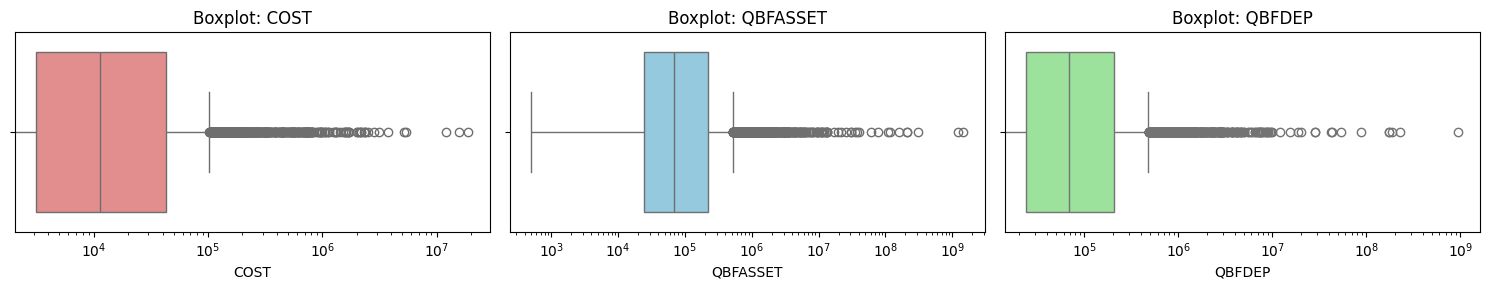

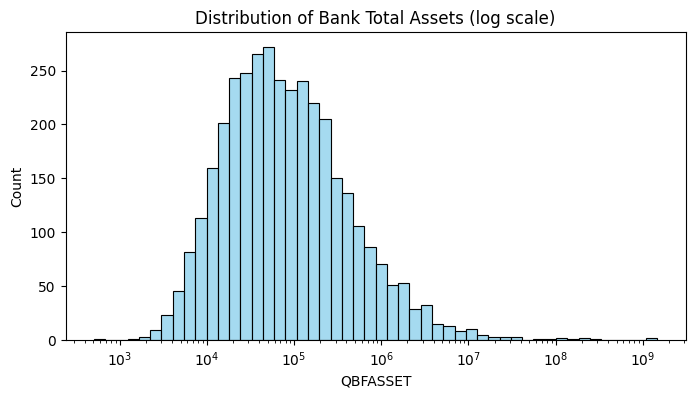

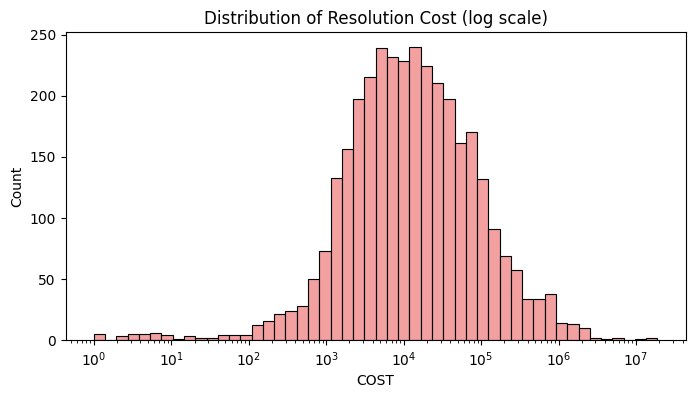

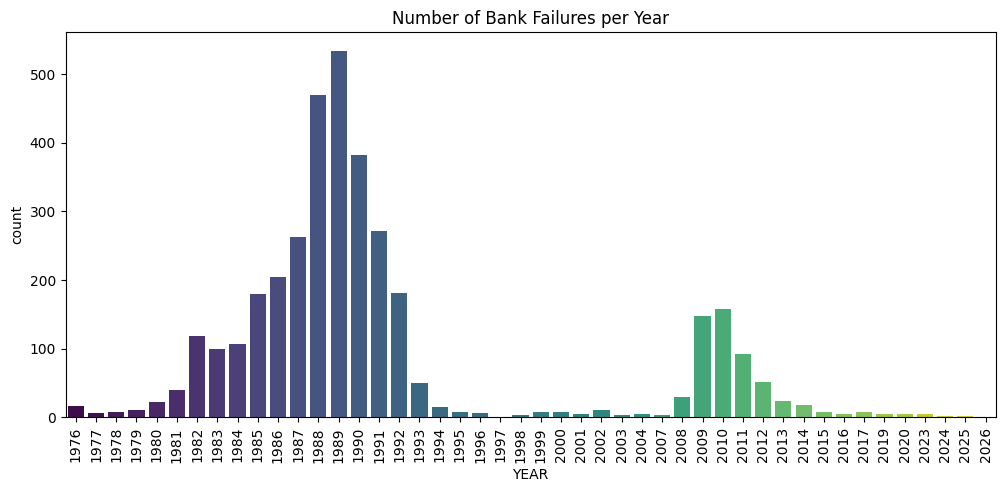

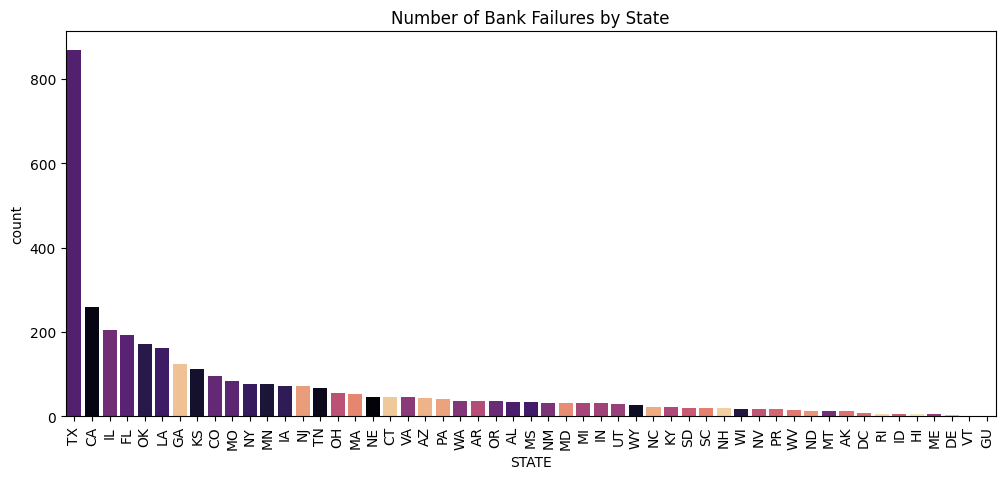

In [6]:
#Univariate Analysis 

# Format Date and State
df['FAILDATE'] = pd.to_datetime(df['FAILDATE'], errors='coerce')
df['YEAR'] = df['FAILDATE'].dt.year
df['STATE'] = df['CITYST'].str[-2:]


print("--- 1. COMPUTATION OF VARIANCE (Continuous Variables) ---")
print(f"Variance of COST: {df['COST'].var():.2f}")
print(f"Variance of QBFASSET: {df['QBFASSET'].var():.2f}")
print(f"Variance of QBFDEP: {df['QBFDEP'].var():.2f}\n")

print("--- 2. NUMBER OF INSTANCES PER CLASSES ---")
print("RESTYPE counts:\n", df['RESTYPE'].value_counts().to_string(), "\n")
print("CHCLASS1 counts:\n", df['CHCLASS1'].value_counts().to_string(), "\n")

print("--- 3. VISUALIZATIONS ---")

# 3.A Boxplots 
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
sns.boxplot(x=df['COST'], ax=axes[0], color='lightcoral').set(title='Boxplot: COST', xscale='log')
sns.boxplot(x=df['QBFASSET'], ax=axes[1], color='skyblue').set(title='Boxplot: QBFASSET', xscale='log')
sns.boxplot(x=df['QBFDEP'], ax=axes[2], color='lightgreen').set(title='Boxplot: QBFDEP', xscale='log')
plt.tight_layout()
plt.show()

# 3.B Distributions (Log Scale)
plt.figure(figsize=(8,4))
sns.histplot(df['QBFASSET'], bins=50, log_scale=True, color='skyblue')
plt.title("Distribution of Bank Total Assets (log scale)")
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(df['COST'], bins=50, log_scale=True, color='lightcoral')
plt.title("Distribution of Resolution Cost (log scale)")
plt.show()

# Failures per Year (to see distribution of bank failure over time)
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='YEAR', hue='YEAR', palette='viridis', legend=False)
plt.xticks(rotation=90)
plt.title("Number of Bank Failures per Year")
plt.show()

# Failures by State
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='STATE', order=df['STATE'].value_counts().index, hue='STATE', palette='magma', legend=False)
plt.xticks(rotation=90)
plt.title("Number of Bank Failures by State")
plt.show()

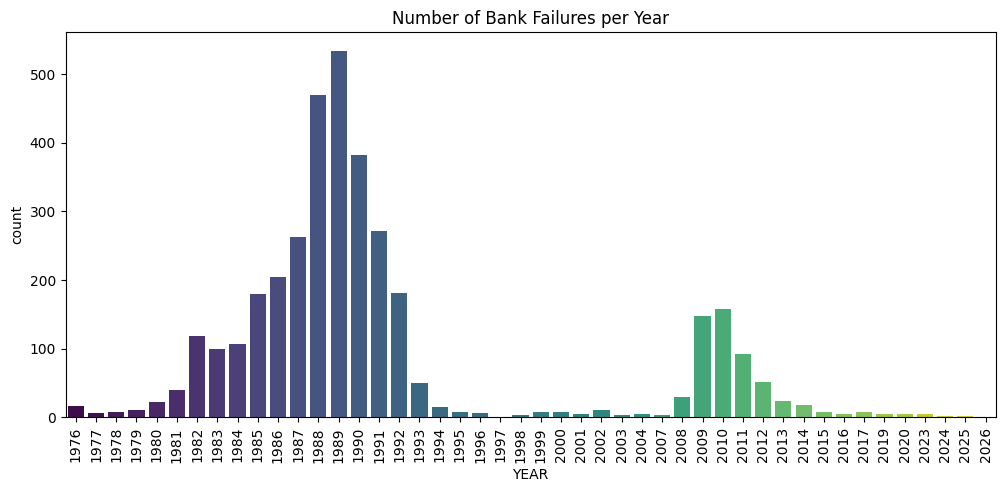

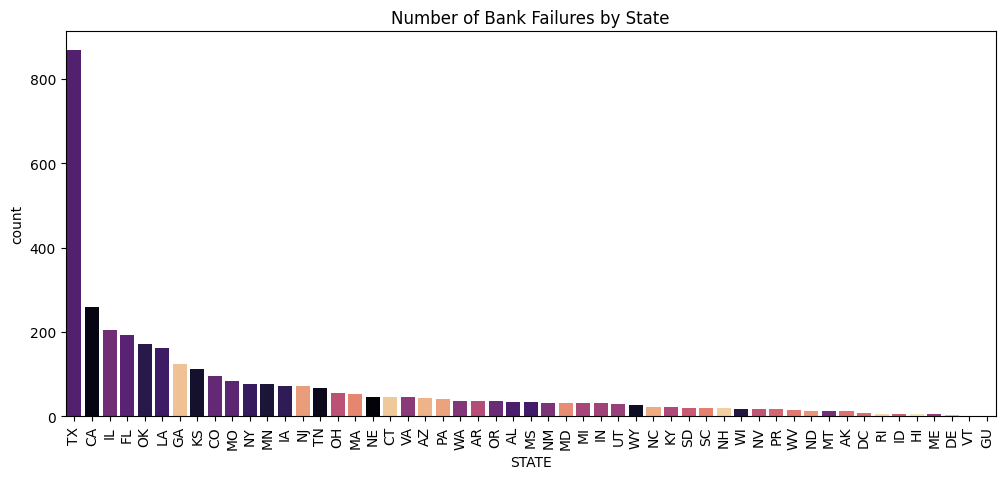

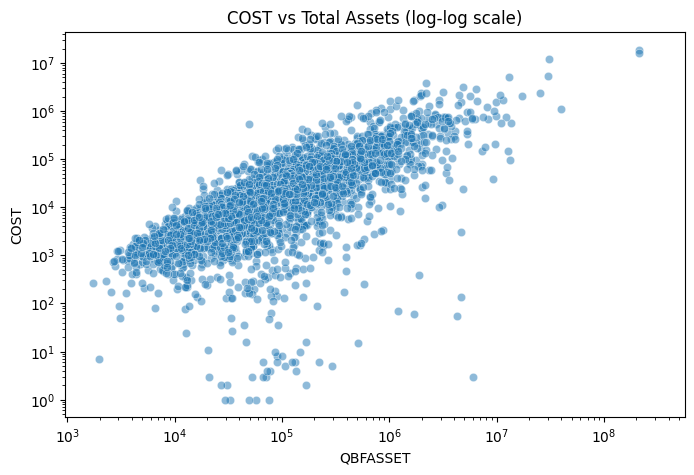

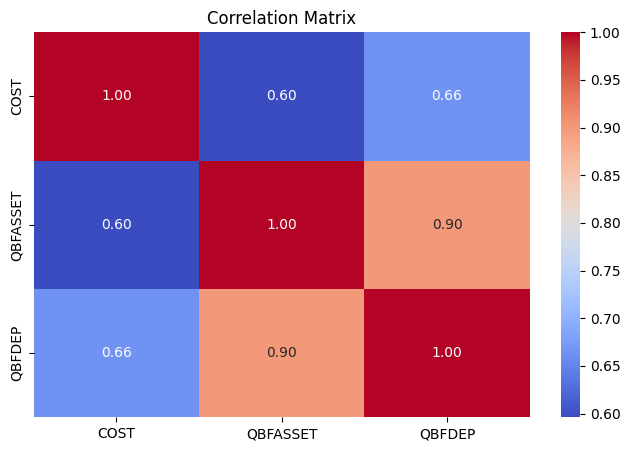

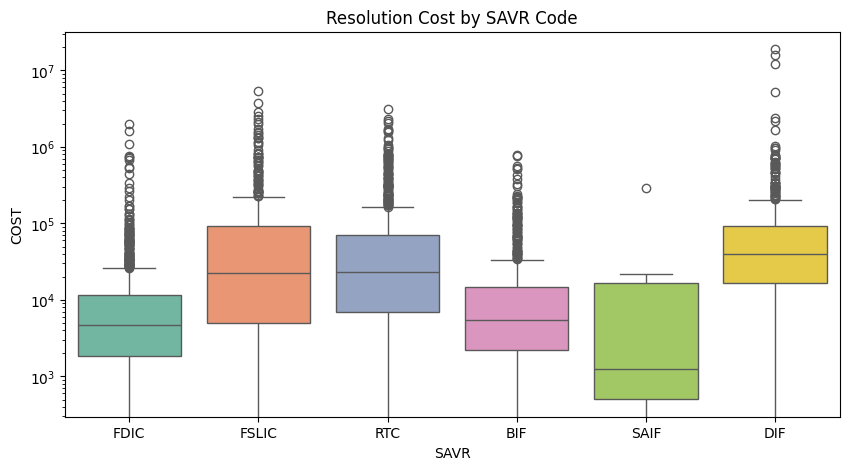

In [ ]:
#Multivariate Analysis 

# COST vs Total Assets
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='QBFASSET', y='COST', alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.title("COST vs Total Assets (log-log scale)")
plt.show()

# Correlation Matrix
plt.figure(figsize=(8,5))
sns.heatmap(df[['COST','QBFASSET','QBFDEP']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Resolution Cost by SAVR
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='SAVR', y='COST', hue='SAVR', palette="Set2", legend=False)
plt.yscale('log')
plt.title("Resolution Cost by SAVR Code")
plt.show()